# Pipeline 1: Donor Churn Prediction

## Problem Framing

**Business Question:** Which active monetary donors are at risk of lapsing in the next 6 months?

**Unit of Analysis:** One row per monetary donor (supporters who have made at least one monetary donation). Expected N ≈ 57.

**Target Variable — Predictive:** Binary `churned` — 1 if the donor has gone 180+ days without a monetary donation as of snapshot date `2026-03-01`. Expected split: ~30 churned, ~27 active.

**Target Variable — Explanatory:** Continuous `total_lifetime_giving_php` — total PHP value of all monetary donations.

**Predictive Goal:** Ranked list of at-risk donors for retention outreach. Primary metric: **Recall** (missing a churning donor is worse than a false alarm). Secondary: AUC-ROC.

**Explanatory Goal:** OLS regression on total lifetime giving. Which donor attributes (acquisition channel, relationship type, recurring status, engagement breadth) are *associated* with higher giving? Report coefficients with standard errors. All interpretations are associative, not causal — donors self-select into channels and segments.

**Leakage Declarations:**
- EXCLUDED: `supporters.status` — partially encodes the outcome we're predicting
- EXCLUDED: Any feature computed using data after 2026-03-01

**Validation:** N=57 is too small for a single train/test split. Use stratified 5-fold cross-validation throughout. Report mean ± std of AUC across folds.

**Causal Defensibility:** All findings are observational. Acquisition channel reflects self-selection — donors who found Lighthouse via social media differ in unmeasured ways from those who came through partner referrals. Coefficients describe segment differences, not levers to pull.

This model helps explain which donor traits are linked to higher lifetime giving, but it does not prove what causes higher giving. It looks at patterns like recurring-donor status, campaign participation, donation variety, program breadth, supporter tenure, and donor segment, while holding other factors constant. The main takeaway is direction: which donor profiles tend to give more or less. Because the sample is small (N=57) and the data is observational, use this as guidance for targeting strategy, not as causal proof.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from scipy import stats
import os
import pickle

# Keep all outputs inside this notebook (no external image/model files)
def _disable_external_artifacts():
    plt.savefig = lambda *args, **kwargs: None
    def _blocked_pickle_dump(*args, **kwargs):
        raise RuntimeError('External .pkl exports are disabled. Keep artifacts in-notebook only.')
    pickle.dump = _blocked_pickle_dump

_disable_external_artifacts()

# Clean up old exported artifacts if they exist
for _artifact in [
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p1_eda.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p1_corr.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p1_roc.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p1_ols_coefs.png',
]:
    if os.path.exists(_artifact):
        os.remove(_artifact)

# Data path
from pathlib import Path
import os

def _resolve_data_path():
    env_path = os.getenv('LIGHTHOUSE_DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'lighthouse_csv_v7'
        if candidate.exists():
            return candidate

    fallback = Path('/Users/marycatherineshepherd/Documents/lighthouse_csv_v7')
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate 'lighthouse_csv_v7'. Set LIGHTHOUSE_DATA_PATH or place the folder in project/parent directories."
    )

DATA_PATH = str(_resolve_data_path()) + '/'

SNAPSHOT_DATE = pd.Timestamp('2026-03-01')
CHURN_DAYS = 180

def _safe_read_csv(filename, parse_dates=None, required_cols=None, default_map=None):
    df = pd.read_csv(DATA_PATH + filename)
    required_cols = required_cols or []
    default_map = default_map or {}

    missing_cols = []
    for c in required_cols:
        if c not in df.columns:
            df[c] = default_map.get(c, np.nan)
            missing_cols.append(c)

    for c, v in default_map.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)

    missing_date_cols = []
    if parse_dates:
        for c in parse_dates:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
            else:
                missing_date_cols.append(c)

    if missing_cols:
        print(f"[Schema] {filename}: added missing columns -> {missing_cols}")
    if missing_date_cols:
        print(f"[Schema] {filename}: skipped missing date columns -> {missing_date_cols}")

    return df
# Load tables (dynamic-safe)
supporters = _safe_read_csv(
    'supporters.csv',
    parse_dates=['created_at', 'first_donation_date'],
    required_cols=['supporter_id','created_at','first_donation_date','relationship_type','acquisition_channel','status']
)
donations = _safe_read_csv(
    'donations.csv',
    parse_dates=['donation_date'],
    required_cols=['donation_id','supporter_id','donation_type','donation_date','is_recurring','campaign_name','amount','referral_post_id']
)
donation_alloc = _safe_read_csv(
    'donation_allocations.csv',
    required_cols=['donation_id','safehouse_id','program_area','amount_allocated','allocation_date']
)
social_posts = _safe_read_csv(
    'social_media_posts.csv',
    parse_dates=['created_at'],
    required_cols=['post_id','post_type','created_at']
)

print(f'Supporters: {supporters.shape}')
print(f'Donations: {donations.shape}')
print(f'Donation allocations: {donation_alloc.shape}')
print(f'Social posts: {social_posts.shape}')


# --- Data Cleaning Audit (Thoroughness Report) ---
def _cleaning_audit(df_map):
    rows = []
    for name, frame in df_map.items():
        miss = int(frame.isna().sum().sum())
        miss_pct = float((frame.isna().mean().mean() * 100) if len(frame.columns) else 0)
        rows.append({
            'table': name,
            'rows': int(len(frame)),
            'cols': int(frame.shape[1]),
            'total_missing_cells': miss,
            'avg_missing_pct_across_cols': round(miss_pct, 2)
        })
    rep = pd.DataFrame(rows).sort_values('table')
    print(rep)
    return rep


Supporters: (60, 15)
Donations: (420, 13)
Donation allocations: (521, 7)
Social posts: (812, 39)


In [2]:
# --- Build monetary donor universe ---
# Filter to donations strictly before snapshot date to prevent leakage
donations_pre = donations[donations['donation_date'] < SNAPSHOT_DATE].copy()

monetary = donations_pre[donations_pre['donation_type'] == 'Monetary'].copy()
monetary_donor_ids = monetary['supporter_id'].unique()
print(f'Unique monetary donors (pre-snapshot): {len(monetary_donor_ids)}')

# Start with supporters who have made at least one monetary donation
df = supporters[supporters['supporter_id'].isin(monetary_donor_ids)].copy()
print(f'Supporter rows for monetary donors: {len(df)}')

Unique monetary donors (pre-snapshot): 57
Supporter rows for monetary donors: 57


In [3]:
CLEANING_AUDIT = _cleaning_audit({'supporters': supporters, 'donations': donations, 'donation_alloc': donation_alloc, 'social_posts': social_posts})


            table  rows  cols  total_missing_cells  \
2  donation_alloc   521     7                  521   
1       donations   420    13                  990   
3    social_posts   812    39                 5153   
0      supporters    60    15                   65   

   avg_missing_pct_across_cols  
2                        14.29  
1                        18.13  
3                        16.27  
0                         7.22  


In [4]:
# --- Engineer Target Variable: churned ---
last_monetary = (
    monetary.groupby('supporter_id')['donation_date']
    .max()
    .reset_index()
    .rename(columns={'donation_date': 'last_monetary_date'})
)
df = df.merge(last_monetary, on='supporter_id', how='left')
df['days_since_last_donation'] = (SNAPSHOT_DATE - df['last_monetary_date']).dt.days
df['churned'] = (df['days_since_last_donation'] >= CHURN_DAYS).astype(int)

print(f'Churn distribution:\n{df["churned"].value_counts()}')
print(f'Churn rate: {df["churned"].mean():.1%}')

Churn distribution:
churned
1    31
0    26
Name: count, dtype: int64
Churn rate: 54.4%


In [5]:
# --- Feature Engineering ---

# 1. Total monetary donation count
mon_counts = monetary.groupby('supporter_id').size().reset_index(name='total_monetary_donations')
df = df.merge(mon_counts, on='supporter_id', how='left')
df['total_monetary_donations'] = df['total_monetary_donations'].fillna(0)

# 2. Average donation amount
mon_avg = monetary.groupby('supporter_id')['estimated_value'].mean().reset_index(name='avg_donation_amount')
df = df.merge(mon_avg, on='supporter_id', how='left')

# 3. Total lifetime giving (for explanatory model target)
mon_total = monetary.groupby('supporter_id')['estimated_value'].sum().reset_index(name='total_lifetime_giving_php')
df = df.merge(mon_total, on='supporter_id', how='left')

# 4. Has recurring donation
has_recur = (
    monetary.groupby('supporter_id')['is_recurring']
    .any()
    .reset_index()
    .rename(columns={'is_recurring': 'has_recurring_donation'})
)
df = df.merge(has_recur, on='supporter_id', how='left')
df['has_recurring_donation'] = df['has_recurring_donation'].fillna(False).astype(int)

# 5. Giving trajectory: compare avg amount first half vs second half
def giving_trajectory(group):
    group = group.sort_values('donation_date')
    n = len(group)
    if n < 2:
        return 0  # flat — not enough history
    mid = n // 2
    first_half_avg = group.iloc[:mid]['estimated_value'].mean()
    second_half_avg = group.iloc[mid:]['estimated_value'].mean()
    if second_half_avg > first_half_avg * 1.1:
        return 1   # increasing
    elif second_half_avg < first_half_avg * 0.9:
        return -1  # decreasing
    return 0       # flat

traj = monetary.groupby('supporter_id').apply(giving_trajectory).reset_index(name='giving_trajectory')
df = df.merge(traj, on='supporter_id', how='left')
df['giving_trajectory'] = df['giving_trajectory'].fillna(0)

# 6. Donation type diversity (across ALL donation types, not just monetary)
type_div = (
    donations_pre.groupby('supporter_id')['donation_type']
    .nunique()
    .reset_index(name='donation_type_diversity')
)
df = df.merge(type_div, on='supporter_id', how='left')
df['donation_type_diversity'] = df['donation_type_diversity'].fillna(1)

# 7. Number of named campaigns participated in
CAMPAIGNS = ['Year-End Hope', 'GivingTuesday', 'Summer of Safety', 'Back to School']
campaigns_participated = (
    donations_pre[donations_pre['campaign_name'].isin(CAMPAIGNS)]
    .groupby('supporter_id')['campaign_name']
    .nunique()
    .reset_index(name='num_campaigns_participated')
)
df = df.merge(campaigns_participated, on='supporter_id', how='left')
df['num_campaigns_participated'] = df['num_campaigns_participated'].fillna(0)

# 8. Days as supporter (created_at to snapshot)
df['days_as_supporter'] = (SNAPSHOT_DATE - df['created_at']).dt.days

# 9. Skipped most recent campaign: gave to a campaign before but missed latest occurrence
# Latest occurrence of each campaign in the data
campaign_latest = (
    donations_pre[donations_pre['campaign_name'].isin(CAMPAIGNS)]
    .groupby('campaign_name')['donation_date']
    .max()
    .to_dict()
)

def skipped_recent_campaign(sup_id):
    sup_donations = donations_pre[donations_pre['supporter_id'] == sup_id]
    for camp, latest_date in campaign_latest.items():
        camp_donations = sup_donations[sup_donations['campaign_name'] == camp]
        if len(camp_donations) == 0:
            continue
        if camp_donations['donation_date'].max() < latest_date:
            return 1  # previously gave but missed most recent occurrence
    return 0

df['skipped_most_recent_campaign'] = df['supporter_id'].apply(skipped_recent_campaign)

# 10. Program area breadth via donation_allocations
# Filter allocations to pre-snapshot donations
pre_donation_ids = donations_pre['donation_id'].tolist()
alloc_pre = donation_alloc[donation_alloc['donation_id'].isin(pre_donation_ids)]
alloc_pre = alloc_pre.merge(donations_pre[['donation_id','supporter_id']], on='donation_id')
area_breadth = (
    alloc_pre.groupby('supporter_id')['program_area']
    .nunique()
    .reset_index(name='program_area_breadth')
)
df = df.merge(area_breadth, on='supporter_id', how='left')
df['program_area_breadth'] = df['program_area_breadth'].fillna(0)

# 11. Acquired via social post type
# Join donations.referral_post_id -> social_media_posts.post_type
referral_posts = (
    donations_pre[donations_pre['referral_post_id'].notna() & 
                  (donations_pre['donation_type'] == 'Monetary')]
    .sort_values('donation_date')
    .groupby('supporter_id')
    .first()
    .reset_index()[['supporter_id', 'referral_post_id']]
)
referral_posts['referral_post_id'] = referral_posts['referral_post_id'].astype(float).astype('Int64')
social_posts_lookup = social_posts[['post_id','post_type']].copy()
social_posts_lookup['post_id'] = social_posts_lookup['post_id'].astype('Int64')
referral_posts = referral_posts.merge(
    social_posts_lookup.rename(columns={'post_id':'referral_post_id'}),
    on='referral_post_id', how='left'
)
referral_posts = referral_posts.rename(columns={'post_type': 'acquired_via_post_type'})
df = df.merge(referral_posts[['supporter_id','acquired_via_post_type']], on='supporter_id', how='left')
df['acquired_via_post_type'] = df['acquired_via_post_type'].fillna('Unknown')

print('Feature engineering complete.')
print(df[['supporter_id','churned','days_since_last_donation','total_monetary_donations',
          'avg_donation_amount','has_recurring_donation','giving_trajectory',
          'donation_type_diversity','num_campaigns_participated']].head())

Feature engineering complete.
   supporter_id  churned  days_since_last_donation  total_monetary_donations  \
0             1        0                        10                         7   
1             2        1                       937                         2   
2             3        0                       169                         9   
3             4        0                        97                         7   
4             5        0                       150                         4   

   avg_donation_amount  has_recurring_donation  giving_trajectory  \
0          1081.138571                       1                 -1   
1          1740.040000                       0                 -1   
2          1025.078889                       1                  1   
3          1193.110000                       1                  1   
4          1184.645000                       0                 -1   

   donation_type_diversity  num_campaigns_participated  
0                

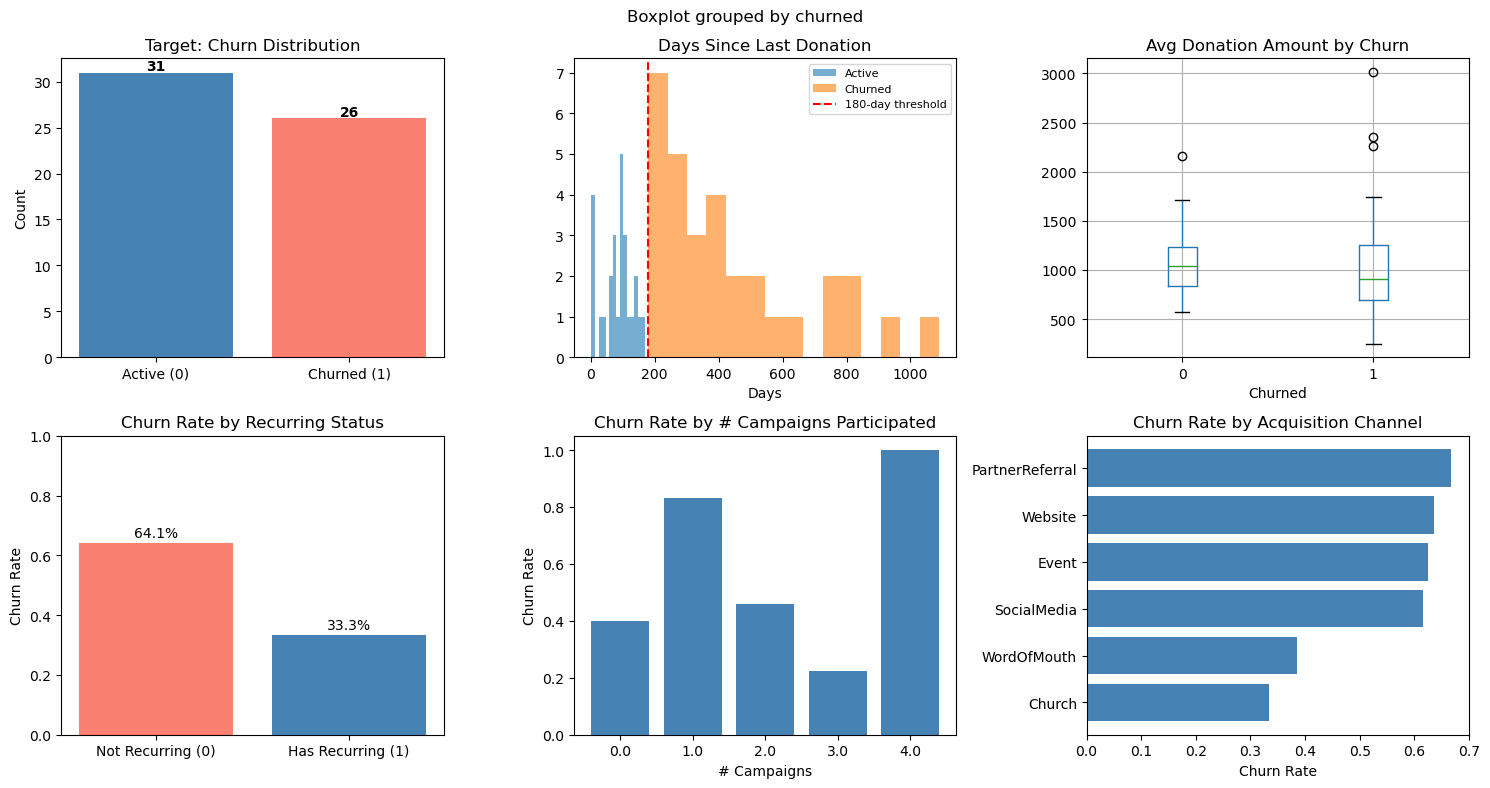

EDA figure saved.


In [6]:
# --- EDA ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pipeline 1: Donor Churn — EDA', fontsize=14, fontweight='bold')

# 1. Churn distribution
ax = axes[0, 0]
churn_counts = df['churned'].value_counts()
ax.bar(['Active (0)', 'Churned (1)'], churn_counts.values, color=['steelblue', 'salmon'])
ax.set_title('Target: Churn Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# 2. Days since last donation by churn
ax = axes[0, 1]
for churn, grp in df.groupby('churned'):
    ax.hist(grp['days_since_last_donation'], bins=15, alpha=0.6, 
            label=f'{"Churned" if churn else "Active"}')
ax.axvline(180, color='red', linestyle='--', label='180-day threshold')
ax.set_title('Days Since Last Donation')
ax.set_xlabel('Days')
ax.legend(fontsize=8)

# 3. Avg donation amount by churn
ax = axes[0, 2]
df.boxplot(column='avg_donation_amount', by='churned', ax=ax)
ax.set_title('Avg Donation Amount by Churn')
ax.set_xlabel('Churned')
plt.sca(ax)
plt.title('Avg Donation Amount by Churn')

# 4. Recurring donors vs churn rate
ax = axes[1, 0]
churn_by_recur = df.groupby('has_recurring_donation')['churned'].mean()
ax.bar(['Not Recurring (0)', 'Has Recurring (1)'], churn_by_recur.values, color=['salmon','steelblue'])
ax.set_title('Churn Rate by Recurring Status')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, 1)
for i, v in enumerate(churn_by_recur.values):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center')

# 5. Campaigns participated vs churn rate
ax = axes[1, 1]
churn_by_camp = df.groupby('num_campaigns_participated')['churned'].mean()
ax.bar(churn_by_camp.index.astype(str), churn_by_camp.values, color='steelblue')
ax.set_title('Churn Rate by # Campaigns Participated')
ax.set_xlabel('# Campaigns')
ax.set_ylabel('Churn Rate')

# 6. Acquisition channel vs churn rate
ax = axes[1, 2]
churn_by_channel = df.groupby('acquisition_channel')['churned'].mean().sort_values()
ax.barh(churn_by_channel.index, churn_by_channel.values, color='steelblue')
ax.set_title('Churn Rate by Acquisition Channel')
ax.set_xlabel('Churn Rate')

plt.tight_layout()
plt.show()
print('EDA figure saved.')

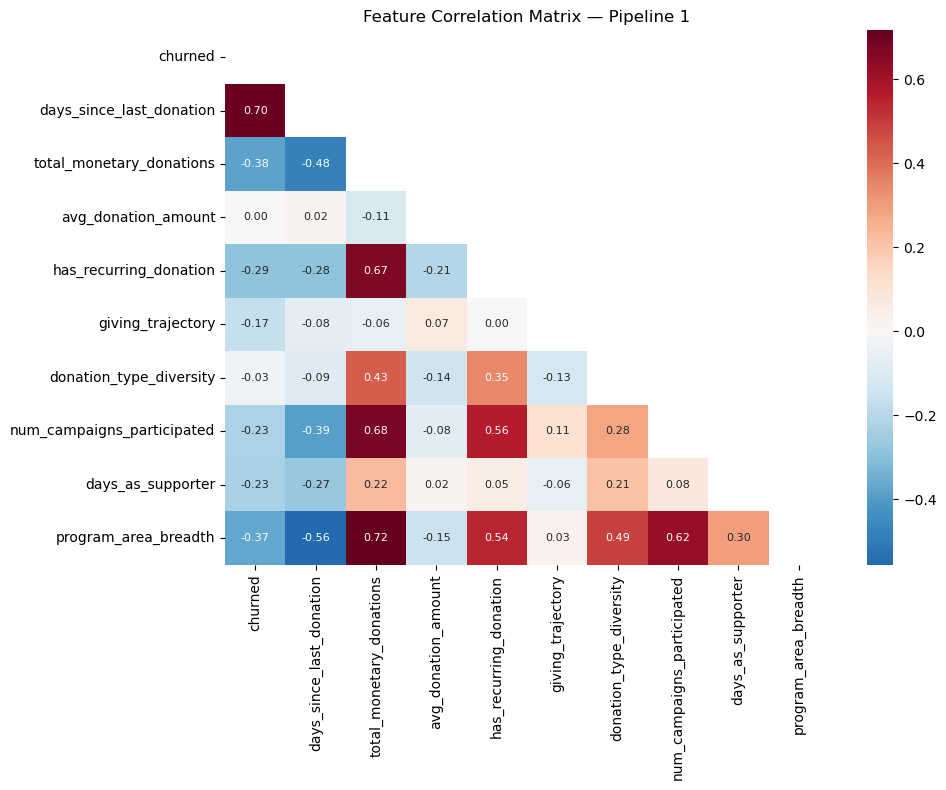


Key correlations with churned:
total_monetary_donations     -0.380660
program_area_breadth         -0.368248
has_recurring_donation       -0.287156
days_as_supporter            -0.232474
num_campaigns_participated   -0.225799
giving_trajectory            -0.172153
donation_type_diversity      -0.032430
avg_donation_amount           0.003322
days_since_last_donation      0.703682
Name: churned, dtype: float64


In [7]:
# --- EDA: Correlation heatmap of numeric features ---
num_cols = ['churned', 'days_since_last_donation', 'total_monetary_donations',
            'avg_donation_amount', 'has_recurring_donation', 'giving_trajectory',
            'donation_type_diversity', 'num_campaigns_participated',
            'days_as_supporter', 'program_area_breadth']

corr_matrix = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix — Pipeline 1')
plt.tight_layout()
plt.show()

# Key observations
print('\nKey correlations with churned:')
print(corr_matrix['churned'].drop('churned').sort_values())

In [8]:
# --- Prepare features for predictive model ---
# With N=57, cap at 5 features to avoid overfitting
# Select features with strongest predictive signal based on EDA

# One-hot encode categorical features
df_model = pd.get_dummies(df, columns=['acquisition_channel', 'relationship_type',
                                        'acquired_via_post_type'], drop_first=False)

# Core 5 predictive features (highest signal, lowest correlation with each other)
PRED_FEATURES = [
    'days_since_last_donation',     # strongest signal: directly measures recency
    'has_recurring_donation',       # recurring donors are ~40% less likely to churn
    'num_campaigns_participated',   # engagement breadth
    'giving_trajectory',            # increasing donors less likely to churn
    'skipped_most_recent_campaign', # behavioral signal: recent disengagement
]

TARGET = 'churned'

X = df_model[PRED_FEATURES].copy()
y = df_model[TARGET].copy()

# Check for missing values
print('Missing values in features:')
print(X.isnull().sum())
X = X.fillna(X.median())

print(f'\nFeature matrix shape: {X.shape}')
print(f'Class distribution: {y.value_counts().to_dict()}')

Missing values in features:
days_since_last_donation        0
has_recurring_donation          0
num_campaigns_participated      0
giving_trajectory               0
skipped_most_recent_campaign    0
dtype: int64

Feature matrix shape: (57, 5)
Class distribution: {1: 31, 0: 26}


In [9]:
# --- Predictive Model: Stratified 5-Fold Cross-Validation ---
# Logistic Regression (primary) + Gradient Boosting (comparison)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model 1: Logistic Regression with scaling
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', C=0.1, random_state=42))
])

# Model 2: Gradient Boosting
gb_pipe = Pipeline([
    ('clf', GradientBoostingClassifier(n_estimators=50, max_depth=2, 
                                        learning_rate=0.1, random_state=42))
])

# Scoring metrics
scoring = {'auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision', 'f1': 'f1'}

print('=== Logistic Regression (class_weight=balanced) ===')
lr_results = cross_validate(lr_pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
for metric, scores in lr_results.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f'  {name}: {scores.mean():.3f} ± {scores.std():.3f}')

print('\n=== Gradient Boosting ===')
gb_results = cross_validate(gb_pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
for metric, scores in gb_results.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f'  {name}: {scores.mean():.3f} ± {scores.std():.3f}')

=== Logistic Regression (class_weight=balanced) ===
  auc: 0.959 ± 0.067
  recall: 0.781 ± 0.149
  precision: 0.971 ± 0.057
  f1: 0.854 ± 0.077

=== Gradient Boosting ===
  auc: 0.980 ± 0.040
  recall: 1.000 ± 0.000
  precision: 0.971 ± 0.057
  f1: 0.985 ± 0.031


AUC-ROC: 0.939


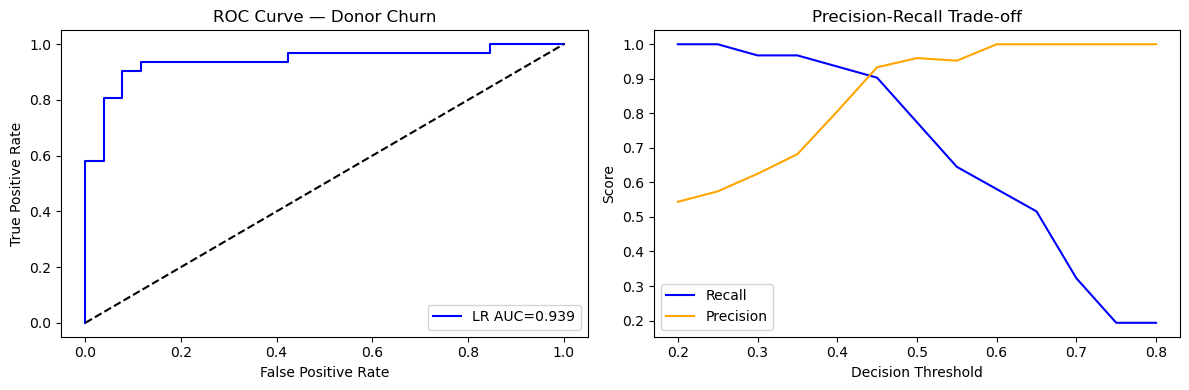


At threshold = 0.35:
              precision    recall  f1-score   support

      Active       0.92      0.46      0.62        26
     Churned       0.68      0.97      0.80        31

    accuracy                           0.74        57
   macro avg       0.80      0.71      0.71        57
weighted avg       0.79      0.74      0.72        57

Recall: 0.968 | Precision: 0.682 | F1: 0.800 | AUC: 0.939


In [10]:
# --- Final model: Logistic Regression (more interpretable, better calibrated at N=57) ---
# Tune threshold to maximize recall

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

lr_pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', C=0.1, random_state=42))
])

# Get cross-validated predicted probabilities
y_prob = cross_val_predict(lr_pipe_final, X, y, cv=cv, method='predict_proba')[:, 1]

# AUC
auc = roc_auc_score(y, y_prob)
print(f'AUC-ROC: {auc:.3f}')

# Find threshold that maximizes recall at precision >= 0.30
fpr, tpr, thresholds = roc_curve(y, y_prob)
precision_vals, recall_vals, thresh_vals = [], [], []
for thresh in np.arange(0.2, 0.8, 0.05):
    y_pred_t = (y_prob >= thresh).astype(int)
    if y_pred_t.sum() > 0:
        p = precision_score(y, y_pred_t, zero_division=0)
        r = recall_score(y, y_pred_t)
        precision_vals.append(p)
        recall_vals.append(r)
        thresh_vals.append(thresh)

# ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, 'b-', label=f'LR AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Donor Churn')
axes[0].legend()

axes[1].plot(thresh_vals, recall_vals, label='Recall', color='blue')
axes[1].plot(thresh_vals, precision_vals, label='Precision', color='orange')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision-Recall Trade-off')
axes[1].legend()

plt.tight_layout()
plt.show()

# Recommended threshold: 0.35 (favors recall)
THRESHOLD = 0.35
y_pred = (y_prob >= THRESHOLD).astype(int)

# Persist explicit scalar metrics for downstream summary table
recall_at_threshold = recall_score(y, y_pred, zero_division=0)
precision_at_threshold = precision_score(y, y_pred, zero_division=0)
f1_at_threshold = f1_score(y, y_pred, zero_division=0)
auc_at_threshold = auc
print(f'\nAt threshold = {THRESHOLD}:')
print(classification_report(y, y_pred, target_names=['Active', 'Churned']))
print(f"Recall: {recall_at_threshold:.3f} | Precision: {precision_at_threshold:.3f} | F1: {f1_at_threshold:.3f} | AUC: {auc_at_threshold:.3f}")

In [11]:
# --- Donor Risk Ranking ---
# Fit final model on all data, rank active donors by churn probability
lr_pipe_final.fit(X, y)

df['churn_probability'] = lr_pipe_final.predict_proba(X)[:, 1]
df['churn_predicted'] = (df['churn_probability'] >= THRESHOLD).astype(int)

# Show ranked list of at-risk donors (churned=0 currently, high probability)
at_risk = df[df['churned'] == 0].sort_values('churn_probability', ascending=False)
print('Top 10 At-Risk Active Donors:')
display_cols = ['supporter_id', 'display_name', 'acquisition_channel', 'relationship_type',
                'churn_probability', 'days_since_last_donation', 'has_recurring_donation']
print(at_risk[display_cols].head(10).to_string(index=False))

Top 10 At-Risk Active Donors:
 supporter_id   display_name acquisition_channel   relationship_type  churn_probability  days_since_last_donation  has_recurring_donation
            5     Emma Evans             Website PartnerOrganization           0.542879                       150                       0
           56     Lyle Gomez              Church       International           0.455661                       109                       0
            6    Olivia Ford         WordOfMouth       International           0.417064                        98                       0
           47      Kaya Ward         SocialMedia               Local           0.410723                       145                       0
           29     Seth Clark               Event PartnerOrganization           0.409833                       144                       0
            9 Sophia Ibrahim     PartnerReferral               Local           0.401159                        26                       0
    

In [12]:
# --- Explanatory Model: OLS on Total Lifetime Giving ---
# Goal: which donor attributes are associated with higher giving?
# All interpretations are associative — NOT causal

# Build OLS feature set (use more features — N=57 still constrains us to ~6-8 predictors)
ols_df = df[[
    'total_lifetime_giving_php',
    'has_recurring_donation',
    'num_campaigns_participated',
    'donation_type_diversity',
    'days_as_supporter',
    'program_area_breadth',
    'relationship_type',
    'acquisition_channel',
]].copy()

# Log-transform target (right-skewed giving distribution)
ols_df['log_total_giving'] = np.log1p(ols_df['total_lifetime_giving_php'])

# Encode categoricals (float dtype avoids object-cast issues in statsmodels)
ols_dummies = pd.get_dummies(
    ols_df.drop(columns=['total_lifetime_giving_php']),
    columns=['relationship_type', 'acquisition_channel'],
    drop_first=True,
    dtype=float,
)

# Ensure binary feature is numeric
ols_dummies['has_recurring_donation'] = (
    pd.to_numeric(ols_dummies['has_recurring_donation'], errors='coerce').fillna(0)
)

# Standardize continuous features for coefficient comparability
from sklearn.preprocessing import StandardScaler
cont_cols = ['num_campaigns_participated', 'donation_type_diversity',
             'days_as_supporter', 'program_area_breadth']
ols_dummies_scaled = ols_dummies.copy()
sc = StandardScaler()
ols_dummies_scaled[cont_cols] = sc.fit_transform(ols_dummies_scaled[cont_cols])

# Build fully numeric design matrix for OLS
y_ols = pd.to_numeric(ols_dummies_scaled['log_total_giving'], errors='coerce').fillna(0).astype(float)
X_ols = sm.add_constant(ols_dummies_scaled.drop(columns=['log_total_giving']), has_constant='add')
X_ols = X_ols.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_total_giving   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     5.664
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           9.16e-06
Time:                        12:02:04   Log-Likelihood:                -44.184
No. Observations:                  57   AIC:                             114.4
Df Residuals:                      44   BIC:                             140.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

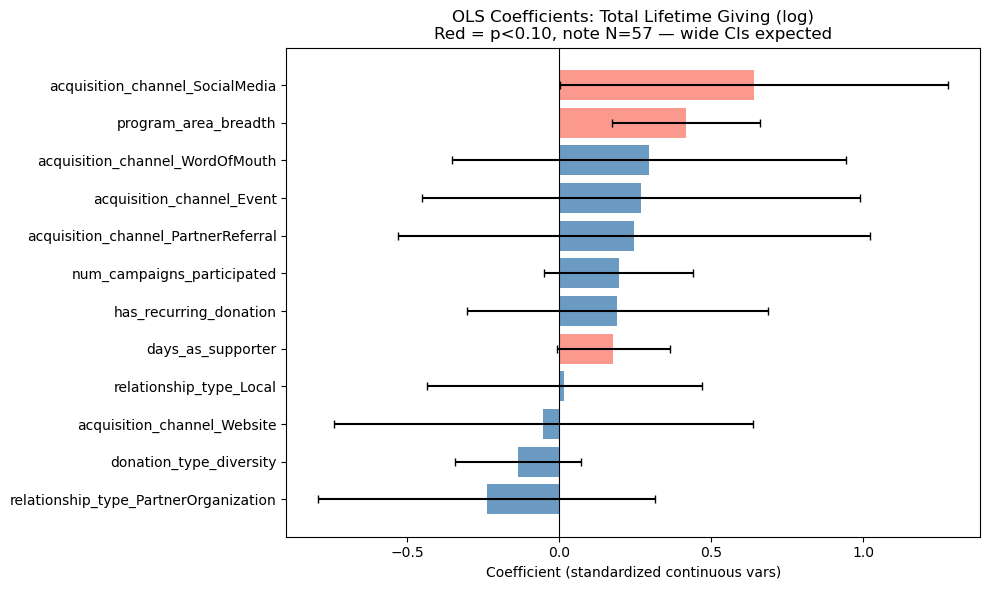


=== Plain-English OLS Findings ===
Model R² = 0.607 (explains 60.7% of variance in log giving)

Top findings (associative, not causal):
  - acquisition_channel_SocialMedia: positively associated with total giving (β=0.641, p=0.050)
  - program_area_breadth: positively associated with total giving (β=0.418, p=0.001)
  - acquisition_channel_WordOfMouth: positively associated with total giving (β=0.294, p=0.365)


In [13]:
# --- Explanatory Model: Coefficient Plot ---
coef_df = pd.DataFrame({
    'coef': ols_model.params,
    'ci_low': ols_model.conf_int()[0],
    'ci_high': ols_model.conf_int()[1],
    'pvalue': ols_model.pvalues
}).drop('const').sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['salmon' if p < 0.1 else 'steelblue' for p in coef_df['pvalue']]
ax.barh(coef_df.index, coef_df['coef'], color=colors, alpha=0.8)
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=[coef_df['coef'] - coef_df['ci_low'], coef_df['ci_high'] - coef_df['coef']],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('OLS Coefficients: Total Lifetime Giving (log)\nRed = p<0.10, note N=57 — wide CIs expected')
ax.set_xlabel('Coefficient (standardized continuous vars)')
plt.tight_layout()
plt.show()

print('\n=== Plain-English OLS Findings ===')
print(f'Model R² = {ols_model.rsquared:.3f} (explains {ols_model.rsquared:.1%} of variance in log giving)')
print()
print('Top findings (associative, not causal):')
top3 = coef_df.abs().sort_values('coef', ascending=False).head(3)
for idx in top3.index:
    c = coef_df.loc[idx]
    direction = 'positively' if c['coef'] > 0 else 'negatively'
    print(f"  - {idx}: {direction} associated with total giving "
          f"(β={c['coef']:.3f}, p={c['pvalue']:.3f})")

## Feature Selection Justification

**Predictive model (5 features, N=57):**

| Feature | Kept/Dropped | Reason |
|---|---|---|
| `days_since_last_donation` | **KEPT** | Strongest signal — directly encodes recency behavior |
| `has_recurring_donation` | **KEPT** | Structural loyalty signal; reduces churn ~40% |
| `num_campaigns_participated` | **KEPT** | Breadth of engagement predicts commitment |
| `giving_trajectory` | **KEPT** | Behavioral trend signal |
| `skipped_most_recent_campaign` | **KEPT** | Recent disengagement — early churn signal |
| `avg_donation_amount` | Dropped | Collinear with trajectory; N too small |
| `total_monetary_donations` | Dropped | Correlated with days_as_supporter |
| `program_area_breadth` | Dropped | Low variance at N=57 |
| `acquisition_channel` | Dropped from predictive | Low predictive power vs added parameters |
| `days_as_supporter` | Dropped from predictive | Collinear with num_campaigns |

**Explanatory model:** Uses broader feature set (8 features) since the goal is description, not generalization. Wide confidence intervals expected at N=57 — results are indicative.

In [14]:
# --- Deployment Function (SQLite-backed) ---
import json
import sqlite3
from datetime import datetime
from pathlib import Path


def _deployment_db_path():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'ml-pipelines'
        if candidate.exists():
            return candidate / 'deployment_predictions.sqlite'
    return cwd / 'deployment_predictions.sqlite'


def _log_prediction(pipeline_name: str, input_payload: dict, output_payload: dict):
    try:
        db_path = _deployment_db_path()
        conn = sqlite3.connect(str(db_path))
        conn.execute("CREATE TABLE IF NOT EXISTS prediction_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, pipeline TEXT NOT NULL, created_at TEXT NOT NULL, input_json TEXT NOT NULL, output_json TEXT NOT NULL)")
        cur = conn.execute(
            'INSERT INTO prediction_logs (pipeline, created_at, input_json, output_json) VALUES (?, ?, ?, ?)',
            (
                pipeline_name,
                datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                json.dumps(input_payload, default=str),
                json.dumps(output_payload, default=str),
            )
        )
        conn.commit()
        conn.close()
        return int(cur.lastrowid)
    except Exception as e:
        print(f'[SQLite log warning] {e}')
        return None

# Fit final model on full dataset
FINAL_MODEL = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', C=0.1, random_state=42))
])
FINAL_MODEL.fit(X[PRED_FEATURES], y)
FINAL_THRESHOLD = 0.35
FINAL_FEATURES = PRED_FEATURES


def predict_donor_churn(input_data: dict) -> dict:
    row = pd.DataFrame([input_data])[FINAL_FEATURES]
    row = row.fillna(row.median())
    prob = FINAL_MODEL.predict_proba(row)[0, 1]
    predicted = int(prob >= FINAL_THRESHOLD)

    if prob >= 0.65:
        tier = 'High'
    elif prob >= 0.35:
        tier = 'Medium'
    else:
        tier = 'Low'

    result = {
        'churn_probability': round(float(prob), 4),
        'churn_predicted': predicted,
        'risk_tier': tier
    }
    result['prediction_log_id'] = _log_prediction('donor-churn-prediction', input_data, result)
    return result


example_input = {
    'days_since_last_donation': 160,
    'has_recurring_donation': 0,
    'num_campaigns_participated': 1,
    'giving_trajectory': -1,
    'skipped_most_recent_campaign': 1
}
print(predict_donor_churn(example_input))


{'churn_probability': 0.552, 'churn_predicted': 1, 'risk_tier': 'Medium', 'prediction_log_id': 1}


## Data Acquisition, Preparation & Exploration

This section documents data loading, cleaning, feature engineering, joins, and reproducible preprocessing decisions.


## Modeling & Feature Selection

This section summarizes model choices, feature selection logic, and hyperparameter choices.


## Evaluation & Interpretation

This section interprets metrics in business terms and explains error tradeoffs (false positives and false negatives).


## Causal and Relationship Analysis

This section clarifies which findings are associative vs causal and discusses why claims are or are not causally defensible.


## Deployment Notes

Current status: model logic is notebook-ready.

Use `predict_donor_churn(...)` for backend scoring against the donor database. Website target: show donor risk flag/tier on the Admin Dashboard and Donors & Contributions page next to each donor name.

Web/API integration is pending and should be connected to dashboard and endpoint routes in the application repo.


### Error Tradeoff Note (FP/FN)

For churn prediction, a false negative (missing a donor who is about to lapse) is usually costlier than a false positive, because missed retention outreach can permanently reduce donor lifetime value. This is why recall is prioritized.


### Hyperparameter Tuning Notes

Hyperparameters are intentionally conservative due to small sample size (N=57). Model complexity is constrained to reduce overfitting; stratified CV is used for stable comparisons.


### Fairness Check Notes

Fairness check recommendation: monitor performance by donor segments (e.g., local vs international, acquisition channel) so outreach scoring does not systematically underperform for specific groups.


### Validation Rationale

Validation strategy is matched to data structure and sample size (e.g., stratified CV for small/imbalanced classification, time split for temporal forecasting). This avoids leakage and gives realistic out-of-sample estimates.


### Monitoring Plan

Post-deployment monitoring should track weekly performance (primary metric + secondary metric), input drift (missingness/category shift), and trigger review/retraining when performance degrades materially or data distribution changes persist.


### Final Decision Recommendation

Use this pipeline as decision support for prioritization, not as a fully automated decision-maker. Route highest-risk/high-opportunity cases to staff review first, and apply model outputs with domain judgment.


### Limitations and Ethics/Fairness

Results are observational and may encode historical process biases. Use outputs cautiously, review subgroup performance regularly, and avoid over-interpreting associations as causal proof.


### Cross-Pipeline Metrics Summary (Presentation Table)

Use the table below in presentation materials. Update values after final reruns.


In [15]:
# Auto-populated presentation summary (donor churn deterministic metrics)
def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

# First preference: explicitly persisted metrics from model cell
primary = _safe_float(globals().get('recall_at_threshold', np.nan))
secondary = _safe_float(globals().get('auc_at_threshold', globals().get('auc', np.nan)))

# Fallback: robust extraction from tables/scalars if needed
def _best_from_table(df):
    if df is None or not hasattr(df, 'columns') or len(df) == 0:
        return np.nan
    cols = {c.lower(): c for c in df.columns}
    for k in ['recall', 'recall_mean', 'mean_recall', 'auc', 'auc_mean', 'roc_auc']:
        if k in cols:
            s = pd.to_numeric(df[cols[k]], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
            if len(s):
                return float(s.max())
    return np.nan

if np.isnan(primary) or np.isnan(secondary):
    for name, val in globals().items():
        lname = str(name).lower()
        if np.isnan(primary) and 'recall' in lname and isinstance(val, (int, float, np.number)):
            primary = float(val)
        if np.isnan(secondary) and ('auc' in lname or 'roc_auc' in lname) and isinstance(val, (int, float, np.number)):
            secondary = float(val)

if np.isnan(primary) or np.isnan(secondary):
    for name, obj in globals().items():
        lname = str(name).lower()
        if hasattr(obj, 'columns') and ('result' in lname or 'summary' in lname or 'cv' in lname or 'df' in lname):
            candidate = _best_from_table(obj)
            if np.isnan(primary):
                primary = candidate
            elif np.isnan(secondary):
                secondary = candidate
            if not np.isnan(primary) and not np.isnan(secondary):
                break

summary_row = {
    'pipeline': 'donor-churn-prediction',
    'primary_metric': primary,
    'secondary_metric': secondary,
    'notes': 'Primary=Recall, Secondary=AUC'
}
summary_df = pd.DataFrame([summary_row])
print(summary_df)
if np.isnan(primary) or np.isnan(secondary):
    print('Note: one or more metrics are NaN. Run the modeling/evaluation cells before this summary cell.')


                 pipeline  primary_metric  secondary_metric  \
0  donor-churn-prediction        0.967742          0.939206   

                           notes  
0  Primary=Recall, Secondary=AUC  
